In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Set directory to tiny_tackers
%cd "/content/drive/My Drive/tiny_tackers"

/content/drive/My Drive/tiny_tackers


In [14]:
# Install and import dependencies
!pip install stable-baselines3 gymnasium pygame

import os
import sys
import time
import pandas as pd
import gymnasium as gym
from IPython.display import clear_output
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
from gymnasium.wrappers import RecordVideo

In [9]:
# Set path to retrieve for gym environment
BASE_ENV_PATH = "/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sailing_gabo-tor"

sys.path.insert(0, BASE_ENV_PATH)

In [10]:
# Import environment and ensure it's comming from my repo
import gym_sailing
print(gym_sailing.__file__)

/content/drive/My Drive/tiny_tackers/gym_sailing_environments/gym_sailing_gabo-tor/gym_sailing/__init__.py


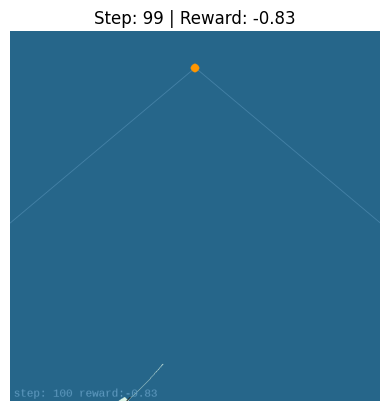

In [19]:
# Use rgb_array instead of human
env = gym.make("Sailboat-v0", render_mode="rgb_array")

observation, info = env.reset(seed=42)

for step in range(100):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    # Get frame and display
    frame = env.render()
    plt.imshow(frame)
    plt.title(f"Step: {step} | Reward: {reward:.2f}")
    plt.axis("off")
    clear_output(wait=True)
    plt.show()

    # time.sleep(0.00)  # controls animation speed

    if terminated or truncated:
        observation, info = env.reset()

import builtins # imported to fix bug with recording video
builtins.quit = lambda *args, **kwargs: None # imported to fix bug with recording video
env.close()